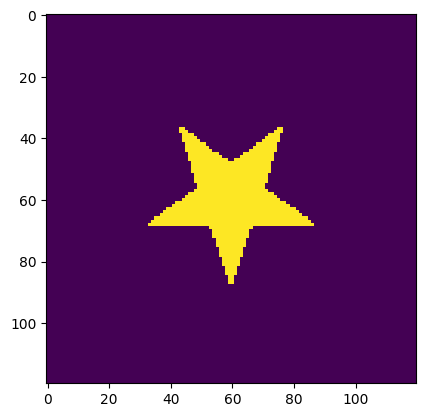

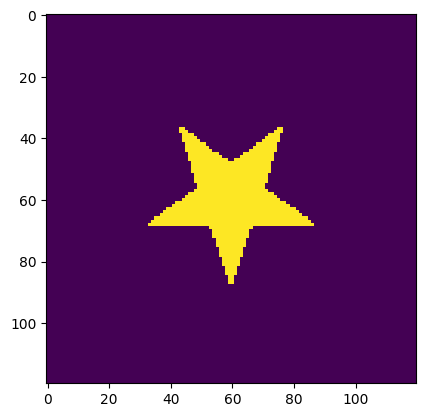

0.8811914560331726


In [1]:
import sys
sys.path.insert(1, '../../eispy2d/library/')
from skimage.metrics import structural_similarity as ssim
from matplotlib import pyplot as plt

import configuration as cfg
import inputdata as ipt
import result as rst
import draw
import mom_cg_fft as mom

# Parameters
name = 'test'
NM = NS = 80
Ro = 4.
lambda_b = 1.
epsilon_rb = 1.
Lx = Ly = 2.
E0 = 1.
perfect_dielectric = True
resolution = (120, 120)
noise = 5.
indicators = [rst.SHAPE_ERROR, rst.POSITION_ERROR]
epsilon_rd = 1.25
l = 0.5
position1 = [.0, .0]

position2 = [.5, .5]

star1, _ = draw.star5(
    l, axis_length_x=Lx, axis_length_y=Ly, resolution=resolution,
    background_rel_permittivity=epsilon_rb, object_rel_permittivity=epsilon_rd,
    center=position1, rotate=0.
)

star2, _ = draw.star5(
    l, axis_length_x=Lx, axis_length_y=Ly, resolution=resolution,
    background_rel_permittivity=epsilon_rb, object_rel_permittivity=epsilon_rd*5,
    center=position1, rotate=0.
)

plt.imshow(star1)
plt.show()

plt.imshow(star2)
plt.show()

data_range1 = star1.max() - star1.min()
data_range2 = star2.max() - star2.min()
if data_range1 > data_range2:
    data_range = data_range1
else:
    data_range = data_range2
ssim_index = ssim(star1, star2, data_range=data_range)
print(ssim_index)

O erro de posição afeta significativamente. O erro de estimativa afeta, mas nem tanto. Ou seja, para comparar com o indicador de posição, bastaria eu mostrar que a dificuldade em recuperar a geometria afetaria na mensuração da capacidade de localização.



In [ ]:
import analytical as ana

name = 'test'
NM = NS = 80
Ro = 4.
lambda_b = 1.
epsilon_rb = 1.
Lx = Ly = 2.
E0 = 1.
perfect_dielectric = True
resolution = (120, 120)
noise = 5.
indicators = [rst.SHAPE_ERROR, rst.POSITION_ERROR, rst.SSIM_ERROR, 
              rst.REL_PERMITTIVITY_PAD_ERROR]
epsilon_rd = 1.25
contrast = (epsilon_rd-epsilon_rb)/epsilon_rb
l = 0.5
position = [.0, .0]

config = cfg.Configuration(name=name + '.cfg', number_measurements=NM, 
                           number_sources=NS, observation_radius=Ro, 
                           wavelength=lambda_b,
                           background_permittivity=epsilon_rb,
                           image_size=[Ly, Lx], magnitude=E0,
                           perfect_dielectric=perfect_dielectric)


test = ipt.InputData(name=name + '.ipt', configuration=config, 
                     resolution=resolution, noise=noise, indicators=indicators)

forward = ana.Analytical(contrast=contrast, radius=l, position=position)
_ = forward.solve(test)

test.draw(show=True)

In [ ]:
import circleapproximation as ca
import stochastic as stc
import richmond as ric

contrast_range = [0., 5.]

discretization = ric.Richmond(configuration=test.configuration,
                              elements=resolution)

method = ca.CircleApproximation(stc.OutputMode(stc.BEST_CASE, reference='ssim'),
                           number_executions=1,
                           contrast_range=contrast_range,
                           solver="de")

result = method.solve(test, discretization, print_info=True)

NameError: name 'discretizationssi' is not defined